## Deep Neural Network from Scratch

In [3]:
import numpy as np 
import matplotlib.pyplot as plt

In [23]:
# simple forward pass

x = np.array([2.0])
y_true = np.array([4.0])

w = np.array([0.5])
b = np.array([0.0])

def forward(x):
    return w * x + b


y_pred = forward(x)
print("Predicted value:", y_pred)



Predicted value: [1.]


In [24]:
# simple loss calculation

loss = (y_pred - y_true) ** 2
print("Loss:", loss)

# we hav to find dl/dw for chain rule but we hav dl/dy and dy/dw 

# backprop

dl_dy = 2 * (y_pred - y_true)
dy_dw = x 

dl_dw  = dl_dy * dy_dw
print("Gradient dl/dw:", dl_dw)


Loss: [9.]
Gradient dl/dw: [-12.]


In [ ]:
# update gradient descent 

learning_rate = 0.1

w = w - (learning_rate * dl_dw)          # it is the formula to of gradient descent like new weight would be old weight - learning rate * gradient

print("Updated weight:", w)             # before we had 0.5 now we have 3.2 from -12*0.1 = -1.2 then add 0.5 to become 1.7

Updated weight: [1.7]


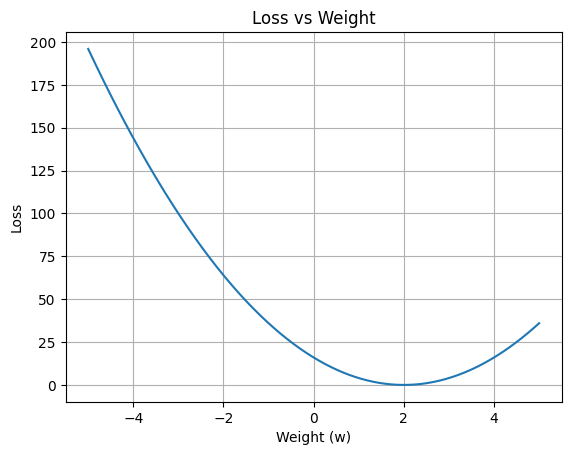

In [29]:
# visualizing

x = 2
y = 4

w_values = np.linspace(-5, 5, 1000)      #means start at -1 end at 2 with 100 points
loss_values = []

for w in w_values:                    # it will calculation all 100 alues from w = =1 to w = 2 
    y_pred = w * x
    loss = (y_pred - y) ** 2
    loss_values.append(loss)
plt.plot(w_values, loss_values)               # it will show how loss changes with weight
plt.xlabel('Weight (w)')
plt.ylabel('Loss')
plt.title('Loss vs Weight')
plt.grid()

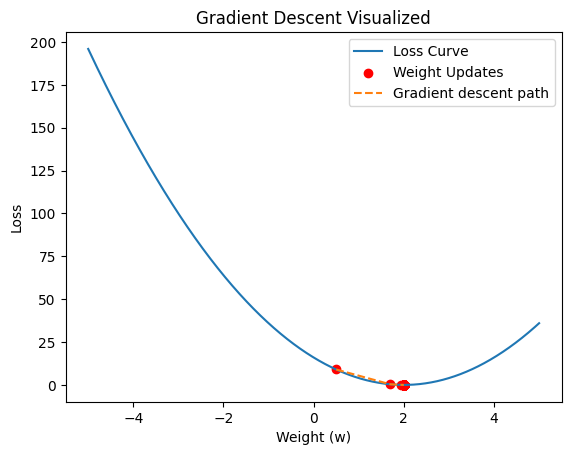

In [31]:
# animation of weight update

w = 0.5
lr = 0.1

steps = []

for i in range(1000):
    y_pred = w * x
    loss = (y_pred - y) ** 2
    dl_dy = 2 * (y_pred - y)
    dy_dw = x
    dl_dw = dl_dy * dy_dw
    steps.append((w, loss))
    w = w - lr * dl_dw

plt.plot(w_values, loss_values, label='Loss Curve')
w_steps = [step[0] for step in steps]
loss_steps = [step[1] for step in steps]

plt.scatter(w_steps, loss_steps, color='red', label='Weight Updates')
plt.plot(w_steps, loss_steps, linestyle="--", label="Gradient descent path")

plt.xlabel("Weight (w)")
plt.ylabel("Loss")
plt.legend()
plt.title("Gradient Descent Visualized")
plt.show()



lets analyze this we had x = 2 and y = 4 means y = 2x so the minimum weight should be 2 at w=2 we have minimum loss and that is our best point as you can see in upper diagram.

And see the red points are weights they start at any random point and it gets more calculation near w = 2 to get the loss minimum.

And the blue line just shows how loss changes our large sequence from 5 to -5 with 1000 points.

## Now lets go for perceptron = multiple input -> one output

In [37]:
#  lets use XOR problem to solve

X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])          # this is niput features 

y = np.array([[0],
              [1],
              [1],
              [0]])               # this is output labels 

# we will create a simple neural network with one hidden layer to solve this problem

def sigmoid(z):
    return 1/ (1+np.exp(-z))

def sigmoid_derivative(z):
    return z * (1 - z)

# initialize weights and biases
np.random.seed(42)                      #for using random sequence same every time

input_size  = 2
hidden_size = 2
output_size = 1

W1 = np.random.rand(input_size, hidden_size)           #it generate random weights 2 for inputs and 2 for hidden layers  
b1 = np.random.rand(1, hidden_size)                     # it geerate only two for hidden layers
W2 = np.random.rand(hidden_size, output_size)         # it generate 2 for hidden layers and 1 for output layer
b2 = np.random.rand(1, output_size)                     # it generate only one for

print("W1, W2:", W1, W2)
print("b1, b2:", b1, b2)


W1, W2: [[0.37454012 0.95071431]
 [0.73199394 0.59865848]] [[0.05808361]
 [0.86617615]]
b1, b2: [[0.15601864 0.15599452]] [[0.60111501]]


Epoch 0, Loss: 0.00020032999168136353
Epoch 1000, Loss: 0.00019874555837426946
Epoch 2000, Loss: 0.00019718556028993213
Epoch 3000, Loss: 0.0001956494410664053
Epoch 4000, Loss: 0.00019413666102188217
Epoch 5000, Loss: 0.00019264669653634836
Epoch 6000, Loss: 0.00019117903946046477
Epoch 7000, Loss: 0.00018973319655031626
Epoch 8000, Loss: 0.0001883086889266997
Epoch 9000, Loss: 0.0001869050515577033
Epoch 10000, Loss: 0.00018552183276346134
Epoch 11000, Loss: 0.0001841585937419481
Epoch 12000, Loss: 0.00018281490811478357
Epoch 13000, Loss: 0.00018149036149209833
Epoch 14000, Loss: 0.00018018455105549045
Epoch 15000, Loss: 0.0001788970851582591
Epoch 16000, Loss: 0.00017762758294203007
Epoch 17000, Loss: 0.00017637567396903872
Epoch 18000, Loss: 0.00017514099786931824
Epoch 19000, Loss: 0.0001739232040020771
Epoch 20000, Loss: 0.00017272195113061882
Epoch 21000, Loss: 0.00017153690711020023
Epoch 22000, Loss: 0.0001703677485881974
Epoch 23000, Loss: 0.00016921416071601254
Epoch 24000,

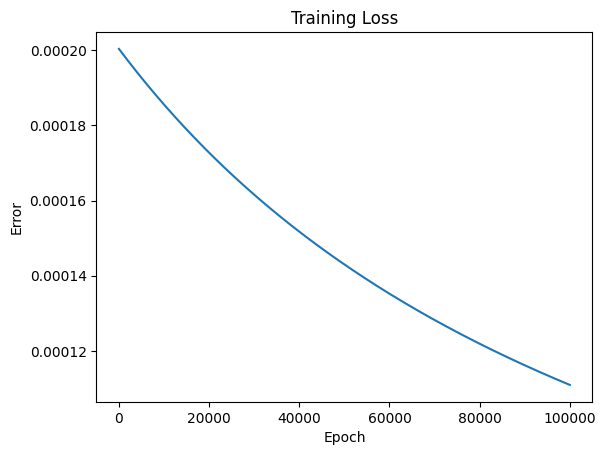

In [54]:
lr = 0.1
epochs = 100000
loss_history = []

for epoch in range(epochs):
    # Forward pass
    hidden_input = np.dot(X, W1) + b1            #it will do the dot product of x and W1 and add b1 its like 1 column of hidden layer
    hidden_output = sigmoid(hidden_input)        #then pass its output to sigmoid function because we hav to introduced non-linearity means it will become big output so take sigmoid to bring it between 0 and 1
    #print("Hidden input before sigoimd:", hidden_input)
    #print("Hidden output after sigoimd :", hidden_output)

    final_input = np.dot(hidden_output, W2) +b2      # same for next hiddne layer
    final_output = sigmoid(final_input)

    #print("Final input before sigmoid:", final_input)
    #print("Final output after sigmoid :", final_output)

    # Compute loss (Mean Squared Error)
    loss = np.mean((y - final_output) ** 2)      #mean square error 
    #print("Loss:", loss)
    
    # Backpropagation

    d_loss_output = 2 * (final_output - y) / y.size    #it is simple loss 2/N * (y_pred - y_true) to find how close we are 
    #print("d_loss_output:", d_loss_output)
    d_output_final_input = sigmoid_derivative(final_output)    # we use sigmoid derivative to find how final output changes with final input                   
    
    #print("d_final_input_W2:", d_output_final_input)
    d_final_input_W2 = hidden_output        # it is like hidden output  
    d_final_input_b2 = 1                       # it is 1 because bias is added directly
    d_hidden_output = W2                        # it is like W2
    d_hidden_input = sigmoid_derivative(hidden_output)                  # it is like hidden output derivative
    d_hidden_input_W1 = X                                # it is like input features
    d_hidden_input_b1 = 1                            # it is 1 because bias is added directly


    # Gradients for W2 and b2
    d_loss_W2 = np.dot(d_final_input_W2.T, d_loss_output * d_output_final_input)     
    #print("d_loss_W2:", d_loss_W2)
    d_loss_b2 = np.sum(d_loss_output * d_output_final_input, axis=0, keepdims=True)
    #print("d_loss_b2:", d_loss_b2)


    # Gradients for W1 and b1
    d_loss_hidden = np.dot(d_loss_output * d_output_final_input, d_hidden_output.T)
    d_loss_W1 = np.dot(d_hidden_input_W1.T, d_loss_hidden * d_hidden_input)
    d_loss_b1 = np.sum(d_loss_hidden * d_hidden_input, axis=0, keepdims=True)   


    # Update weights and biases
    W2 -= lr * d_loss_W2
    b2 -= lr * d_loss_b2
    W1 -= lr * d_loss_W1
    b1 -= lr * d_loss_b1   

    loss_history.append(loss)

    if epoch % 1000 == 0:
        print(f'Epoch {epoch}, Loss: {loss}')   

plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.show()


In [56]:
print("\nFinal Results")

#forward pass
h_in = np.dot(X, W1) + b1
h_out = sigmoid(h_in)
f_in = np.dot(h_out, W2) + b2
prediction = sigmoid(f_in)

print(f"{'Input':<15} | {'Target':<8} | {'Prediction':<15} | {'Rounded'}")
print("-" * 55)

for i in range(len(X)):
    input_str = str(X[i])                # e.g., "[0 1]"
    target_val = y[i][0]                 # e.g., 1
    pred_val = prediction[i][0]          # e.g., 0.9843...
    rounded_val = int(np.round(pred_val)) # e.g., 1
    
    print(f"{input_str:<15} | {target_val:<8} | {pred_val:.8f}      | {rounded_val}")

print("-" * 55)




Final Results
Input           | Target   | Prediction      | Rounded
-------------------------------------------------------
[0 0]           | 0        | 0.01174198      | 0
[0 1]           | 1        | 0.98999644      | 1
[1 0]           | 1        | 0.98998706      | 1
[1 1]           | 0        | 0.01027608      | 0
-------------------------------------------------------
